In [1]:
import numpy as np

vol_path = "/home/public/CTSpine1K/data/data-MHD_ctpro_woMask1/1.3.6.1.4.1.9328.50.4.0402/volume_gt.npy"
vol = np.load(vol_path)
print(vol.shape)

(512, 512, 512)


shape = (512, 512, 512)
dtype = float32

Data generation script shows: volume_gt.npy is stored as XYZ order.
axis0 -> X (left-right)
axis1 -> Y (posterior-anterior)
axis2 -> Z (inferior-superior / axial)

X / sagittal:
  full_index_range = 0:511
  slice_shape = (512, 512)
  min/max/mean = -113.419 / 2549.691 / 384.509
  nonzero_bbox_rows = 57:440
  nonzero_bbox_cols = 29:481

Y / coronal:
  full_index_range = 0:511
  slice_shape = (512, 512)
  min/max/mean = -64.515 / 3082.756 / 552.974
  nonzero_bbox_rows = 56:455
  nonzero_bbox_cols = 29:481

Z / axial:
  full_index_range = 0:511
  slice_shape = (512, 512)
  min/max/mean = -97.559 / 2719.589 / 234.695
  nonzero_bbox_rows = 56:455
  nonzero_bbox_cols = 57:422



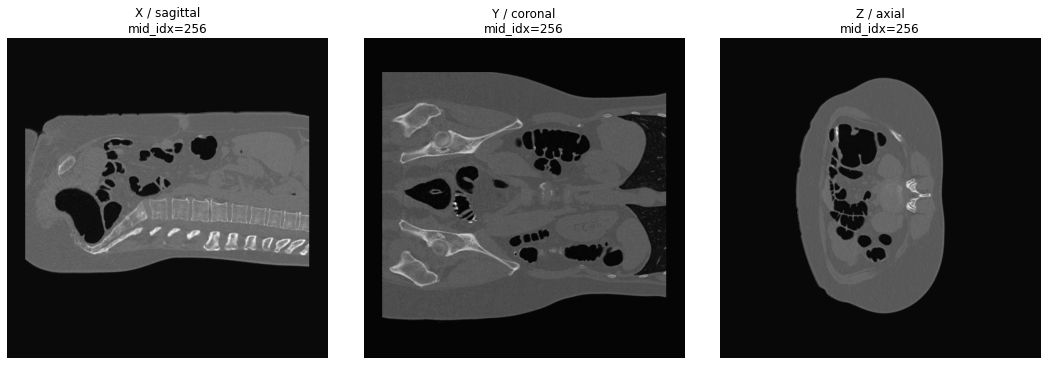

In [3]:
import numpy as np
import matplotlib.pyplot as plt

vol_path = "/home/public/CTSpine1K/data/data-MHD_ctpro_woMask1/1.3.6.1.4.1.9328.50.4.0402/volume_gt.npy"
vol = np.load(vol_path)
print('shape =', vol.shape)
print('dtype =', vol.dtype)
print()
print('Data generation script shows: volume_gt.npy is stored as XYZ order.')
print('axis0 -> X (left-right)')
print('axis1 -> Y (posterior-anterior)')
print('axis2 -> Z (inferior-superior / axial)')
print()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axis_info = [(0, 'X / sagittal'), (1, 'Y / coronal'), (2, 'Z / axial')]
for ax, (axis, title) in zip(axes, axis_info):
    idx = vol.shape[axis] // 2
    sl = np.take(vol, idx, axis=axis)
    ax.imshow(sl, cmap='gray')
    ax.set_title(f'{title}\nmid_idx={idx}')
    ax.axis('off')
    nz = np.argwhere(sl != 0)
    print(f'{title}:')
    print(f'  full_index_range = 0:{vol.shape[axis]-1}')
    print(f'  slice_shape = {sl.shape}')
    print(f'  min/max/mean = {sl.min():.3f} / {sl.max():.3f} / {sl.mean():.3f}')
    if nz.size:
        mins = nz.min(axis=0)
        maxs = nz.max(axis=0)
        print(f'  nonzero_bbox_rows = {mins[0]}:{maxs[0]}')
        print(f'  nonzero_bbox_cols = {mins[1]}:{maxs[1]}')
    else:
        print('  nonzero_bbox = None')
    print()

plt.tight_layout()
plt.show()


In [2]:
import os
import numpy as np
import SimpleITK as sitk

case_dir = "/home/public/CTSpine1K/data/data-MHD_ctpro_woMask1/volume-covid19-A-0382_ct/"

paths = {
    "ct_file.mha": os.path.join(case_dir, "ct_file.mha"),
    "vol_pred.npy": os.path.join(case_dir, "vol_pred.npy"),
    "volume_gt.npy": os.path.join(case_dir, "volume_gt.npy"),
}

def print_stats(name, arr):
    arr = np.asarray(arr)
    print(f"{name}:")
    print(f"  shape={arr.shape}, dtype={arr.dtype}")
    print(f"  min={float(arr.min()):.6f}, max={float(arr.max()):.6f}, mean={float(arr.mean()):.6f}")
    print()

for name, p in paths.items():
    if not os.path.exists(p):
        print(f"{name}: NOT FOUND -> {p}")
        print()
        continue

    if p.endswith(".mha"):
        img = sitk.ReadImage(p)
        arr_zyx = sitk.GetArrayFromImage(img)
        print_stats(name, arr_zyx)
    else:
        arr = np.load(p, mmap_mode="r")
        print_stats(name, arr)


ct_file.mha:
  shape=(305, 512, 512), dtype=float64
  min=-462.451348, max=2927.632592, mean=154.337329

vol_pred.npy:
  shape=(512, 512, 512), dtype=float32
  min=0.000000, max=8.087698, mean=0.031904

volume_gt.npy:
  shape=(512, 512, 512), dtype=float32
  min=0.000000, max=8.087698, mean=0.031904

volume_gt.npy:
  shape=(512, 512, 512), dtype=float32
  min=0.000000, max=0.975878, mean=0.030708

  min=0.000000, max=0.975878, mean=0.030708



In [ ]:
import os
import numpy as np

try:
    import SimpleITK as sitk
except Exception:
    sitk = None

case_dir = "/home/public/CTSpine1K/data/data-MHD_ctpro_woMask1/volume-covid19-A-0380_ct/"

paths = {
    "ct_file.mha": os.path.join(case_dir, "ct_file.mha"),
    "vol_pred.npy": os.path.join(case_dir, "vol_pred.npy"),
    "volume_gt.npy": os.path.join(case_dir, "volume_gt.npy"),
}


def print_stats(name, arr, fmt="{:.6f}"):
    a = np.asarray(arr)
    print(f"{name}:")
    print(f"  shape = {a.shape}")
    print(f"  dtype = {a.dtype}")
    print(f"  min  = {fmt.format(float(a.min()))}")
    print(f"  max  = {fmt.format(float(a.max()))}")
    print(f"  mean = {fmt.format(float(a.mean()))}")
    print(f"  std  = {fmt.format(float(a.std()))}")
    print("")

for name, p in paths.items():
    if not os.path.exists(p):
        print(f"{name}: NOT FOUND -> {p}\n")
        continue

    try:
        if p.endswith('.mha'):
            if sitk is None:
                print(f"{name}: SimpleITK not available, cannot read .mha -> {p}\n")
                continue
            img = sitk.ReadImage(p)
            arr_zyx = sitk.GetArrayFromImage(img)  # Z, Y, X order
            print_stats(name + " (ZYX order from SimpleITK)", arr_zyx)
        else:
            arr = np.load(p, mmap_mode='r')
            print_stats(name, arr)
    except Exception as e:
        print(f"{name}: ERROR reading {p}: {e}\n")


ct_file.mha (ZYX order from SimpleITK):
  shape = (305, 512, 512)
  dtype = float64
  min = -462.451348
  max = 2927.632592
  mean = 154.337329
  std = 366.339298

vol_pred.npy:
  shape = (512, 512, 512)
  dtype = float32
  min = 0.000000
  std = 366.339298

vol_pred.npy:
  shape = (512, 512, 512)
  dtype = float32
  min = 0.000000
  max = 8.087698
  mean = 0.031904
  max = 8.087698
  mean = 0.031904
  std = 0.087135

volume_gt.npy:
  shape = (512, 512, 512)
  dtype = float32
  min = 0.000000
  std = 0.087135

volume_gt.npy:
  shape = (512, 512, 512)
  dtype = float32
  min = 0.000000
  max = 0.975878
  mean = 0.030708
  max = 0.975878
  mean = 0.030708
  std = 0.097548

  std = 0.097548



In [5]:
import torch
from pathlib import Path

case_dir = Path("data/LUNA16_0828_1.3.6.1.4.1.14519.5.2.1.6279.6001.193721075067404532739943086458")
case_id = case_dir.name
xray_1 = torch.load(case_dir / f"{case_id}_xray_1.pt", map_location="cpu")
xray_2 = torch.load(case_dir / f"{case_id}_xray_2.pt", map_location="cpu")

print("xray_1 size:", xray_1.size())
print("xray_2 size:", xray_2.size())


xray_1 size: torch.Size([1, 768])
xray_2 size: torch.Size([1, 768])


CT volume shape: (512, 512, 482)
Mask volume shape: (512, 512, 482)
Unified slice ratio: 0.5
Chosen indices -> axial: 240, coronal: 256, sagittal: 256
X-ray 1 shape: (512, 512) from 1.3.6.1.4.1.9328.50.4.0051_xray1.pfm
X-ray 2 shape: (512, 512) from 1.3.6.1.4.1.9328.50.4.0051_xray2.pfm


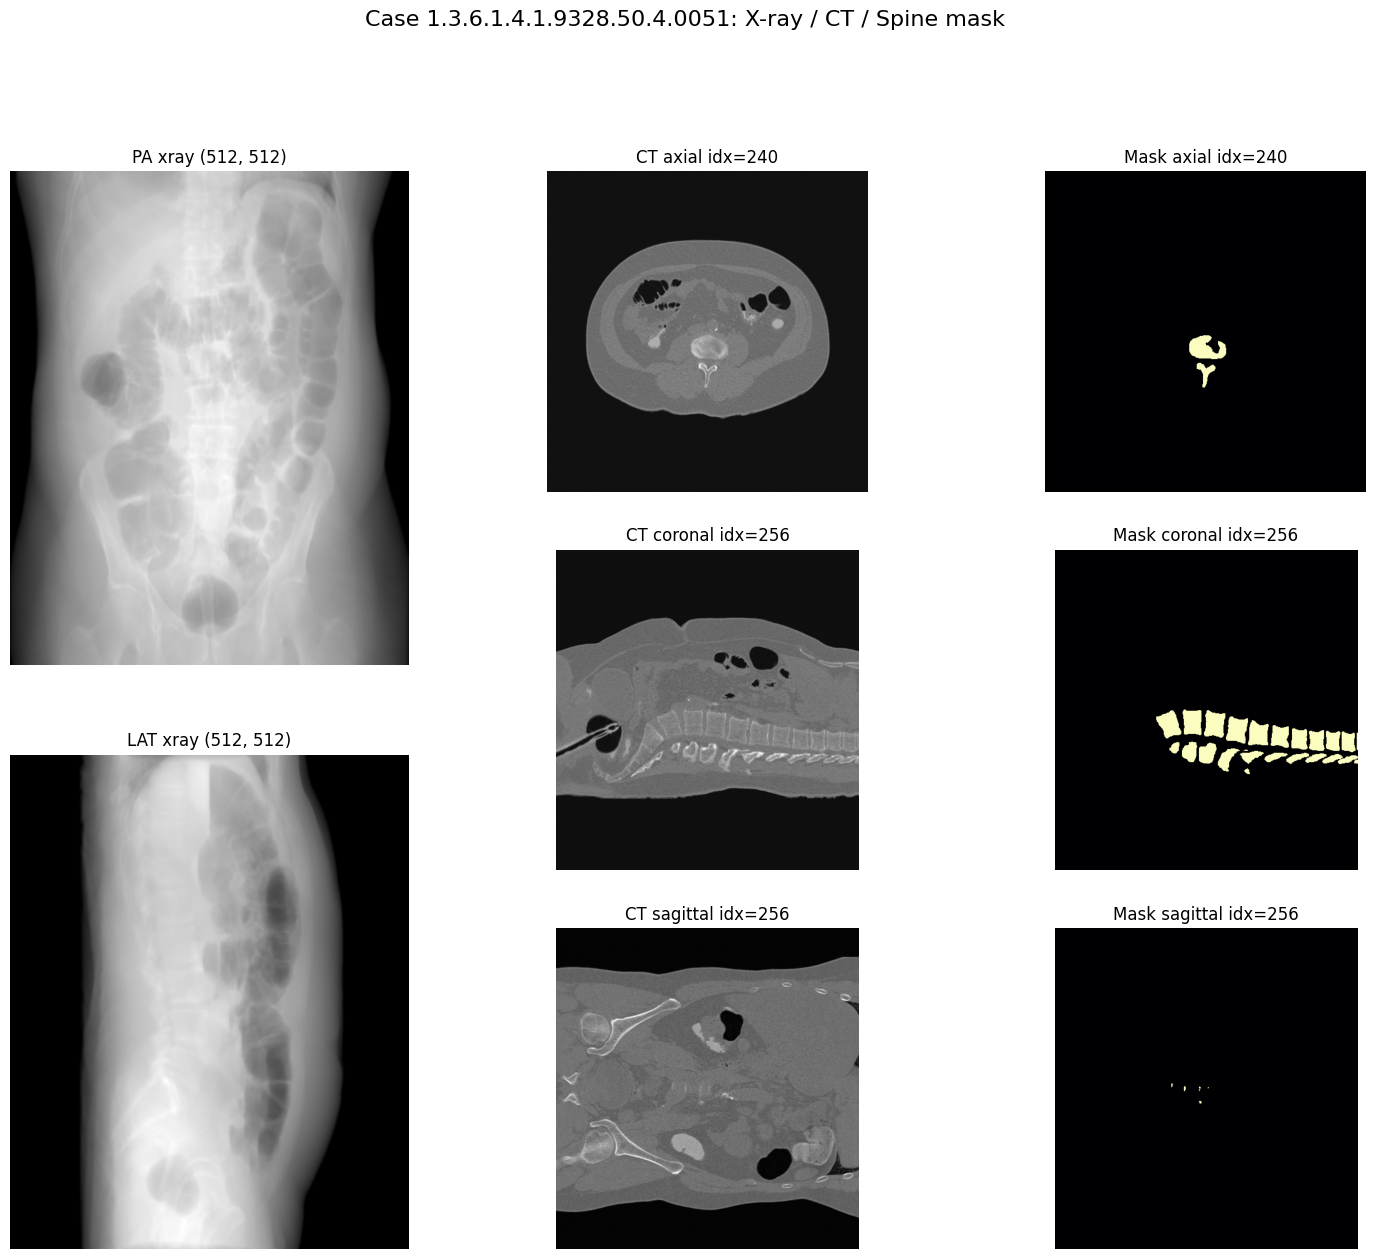

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

case_dir = Path('/root/epfs/data/1.3.6.1.4.1.9328.50.4.0051')
case_id = case_dir.name
xray_dir = Path('/root/epfs/data-HDF5-512_ct512_plastimatch_xray')


def load_axial_stack(folder, key):
    paths = sorted(Path(folder).glob('axial_*.npz'))
    if not paths:
        raise FileNotFoundError(f'No axial_*.npz files found under {folder}')
    slices = []
    for path in paths:
        with np.load(path) as data:
            if key not in data.files:
                raise KeyError(f'{path} does not contain key {key!r}; available keys: {data.files}')
            slices.append(data[key].astype(np.float32))
    return np.stack(slices, axis=-1)


def load_pfm(path):
    with open(path, 'rb') as f:
        header = f.readline().decode('ascii').strip()
        if header not in {'Pf', 'PF'}:
            raise ValueError(f'Unsupported PFM header {header!r} in {path}')
        dims = f.readline().decode('ascii').strip()
        while dims.startswith('#') or not dims:
            dims = f.readline().decode('ascii').strip()
        width, height = map(int, dims.split())
        scale = float(f.readline().decode('ascii').strip())
        endian = '<' if scale < 0 else '>'
        data = np.fromfile(f, endian + 'f')
    channels = 3 if header == 'PF' else 1
    expected = width * height * channels
    if data.size != expected:
        raise ValueError(f'PFM size mismatch in {path}: expected {expected} floats, got {data.size}')
    if channels == 3:
        array = data.reshape((height, width, 3))
        array = array[:, :, ::-1]
    else:
        array = data.reshape((height, width))
    array = np.flipud(array).astype(np.float32)
    return array


def load_tensor(path):
    return torch.load(path, map_location='cpu').detach().cpu().float()


def tensor_to_display_array(tensor):
    array = np.asarray(tensor.numpy()).squeeze()
    if array.ndim == 1:
        array = array[None, :]
    return array


def pick_slice_indices(mask_volume):
    # choose the slice with largest mask area along each plane
    axial_index = int(np.argmax(mask_volume.sum(axis=(0, 1))))
    coronal_index = int(np.argmax(mask_volume.sum(axis=(0, 2))))
    sagittal_index = int(np.argmax(mask_volume.sum(axis=(1, 2))))
    return axial_index, coronal_index, sagittal_index

def slice_view(volume, plane, index):
    if plane == 'axial':
        return volume[:, :, index]
    if plane == 'coronal':
        return volume[:, index, :]
    if plane == 'sagittal':
        return volume[index, :, :]
    raise ValueError(f'Unknown plane: {plane}')


ct_volume = load_axial_stack(case_dir / 'gt', key='ct')
mask_volume = load_axial_stack(case_dir / 'mask', key='gt_mask')

xray1_path = xray_dir / f'{case_id}_xray1.pfm'
xray2_path = xray_dir / f'{case_id}_xray2.pfm'
xray1 = load_pfm(xray1_path)
xray2 = load_pfm(xray2_path)

# pick per-plane slices based on mask (max mask area) -> restores previous behaviour
axial_idx, coronal_idx, sagittal_idx = pick_slice_indices(mask_volume)
print(f'CT volume shape: {ct_volume.shape}')
print(f'Mask volume shape: {mask_volume.shape}')
print(f'Chosen indices -> axial: {axial_idx}, coronal: {coronal_idx}, sagittal: {sagittal_idx}')
print(f'X-ray 1 shape: {xray1.shape} from {xray1_path.name}')
print(f'X-ray 2 shape: {xray2.shape} from {xray2_path.name}')

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(1, 3, wspace=0.25)

left = gs[0, 0].subgridspec(2, 1, hspace=0.18)
center = gs[0, 1].subgridspec(3, 1, hspace=0.18)
right = gs[0, 2].subgridspec(3, 1, hspace=0.18)

xray_items = [
    (xray1, 'PA'),
    (xray2, 'LAT'),
]
for row, (array, title) in enumerate(xray_items):
    ax = fig.add_subplot(left[row, 0])
    if array.ndim == 3 and array.shape[-1] == 3:
        display_array = np.clip(array, 0, 1)
        ax.imshow(display_array)
    else:
        display_array = np.asarray(array).squeeze()
        if display_array.ndim == 1:
            display_array = display_array[None, :]
        ax.imshow(display_array, cmap='gray', aspect='auto')
    ax.set_title(f'{title} xray {tuple(np.asarray(array).shape)}')
    ax.axis('off')

planes = [
    ('axial', axial_idx),
    ('coronal', coronal_idx),
    ('sagittal', sagittal_idx),
]
for row, (plane, index) in enumerate(planes):
    ct_slice = slice_view(ct_volume, plane, index)
    mask_slice = slice_view(mask_volume, plane, index)

    ax_ct = fig.add_subplot(center[row, 0])
    ax_ct.imshow(ct_slice, cmap='gray')
    ax_ct.set_title(f'CT {plane} idx={index}')
    ax_ct.axis('off')

    ax_mask = fig.add_subplot(right[row, 0])
    ax_mask.imshow(mask_slice, cmap='magma', vmin=0, vmax=1)
    ax_mask.set_title(f'Mask {plane} idx={index}')
    ax_mask.axis('off')

fig.suptitle(f'Case {case_id}: X-ray / CT / Spine mask', y=0.995, fontsize=16)
plt.show()
